In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [2]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

parsing /Users/emcbride/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available


/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)

In [7]:
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

normed_bias = []
sampled_params = []
sampled_sims = []

mean_params = []

bad = np.load(f"{base_dir}/metadata/badsims_emulated.npy", allow_pickle=True)
good = np.load(f"{base_dir}/metadata/goodsims_emulated.npy", allow_pickle=True)

fig = plt.figure()

for i in range(10):
    directory = f"{base_dir}/inference/biases/samples_{i}"
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        print(filepath)

        match = pattern.search(filename)
        if match:
            sn = match[0]
            if sn in sampled_sims:
                print(f'resampled')
                continue
            true_params = np.asarray([*df.loc[sn].to_numpy()])#,
                                    #    *whatthetau(df.loc[sn].to_numpy())])

            if not os.path.exists(f"{filepath}/saved_chains.h5"):
                continue
            s, l = utils.load_samples(filepath)
        #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
            chain = s[:,:-1]
            print()
            print(f"chains shape is {chain.shape}")
            print()
            means = np.mean(chain, axis=0)
            stds = np.std(chain, axis=0)

            mean_params.append(means)

            nbias = (means - true_params[2:]) / stds
            normed_bias.append(nbias)

            sampled_params.append(true_params)
            sampled_sims.append(sn)

# directory = f"{base_dir}/inference/biases/samples1"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

# directory = f"{base_dir}/inference/biases/samples3"
# for filename in os.listdir(directory):
#     filepath = os.path.join(directory, filename)
#     print(filepath)

#     match = pattern.search(filename)
#     if match:
#         sn = match[0]
#         if sn in sampled_sims:
#             print('resampled')
#             continue
#         true_params = np.asarray([*df.loc[sn].to_numpy()])#,
#                                 #    *whatthetau(df.loc[sn].to_numpy())])
#         s, l = utils.load_samples(filepath)
#      #   chain = make_tauchains(s, truths=df.loc[sn].to_dict())
#         chain = s[:,:-1]
#         means = np.mean(chain, axis=0)
#         stds = np.std(chain, axis=0)

#         nbias = (means - true_params[2:]) / stds
#         normed_bias.append(nbias)

#         sampled_params.append(true_params)
#         sampled_sims.append(sn)
#         # fig = corner.corner(chain, fig=fig)

normed_bias = np.asarray(normed_bias)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10809
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10809...

chains shape is (60000, 3)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu17242
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu17242...

chains shape is (60000, 3)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu16216
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu16216...

chains shape is (60000, 3)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu13192
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu13192...

chains shape is (2400, 3)

/Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10988
Loading samples from /Users/emcbride/Datasets/LoReLi/inference/biases/samples_0/bias_simu10988...

chains shape is (60000, 

<Figure size 640x480 with 0 Axes>

In [9]:
normed_bias.shape

(77, 3)

In [58]:
s2, l2 = utils.load_samples(f"{base_dir}/inference/productionruns3_mechaemu_simu10818_10emus/CMB-HD/noiseless/")


Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818_10emus/CMB-HD/noiseless/...


In [59]:
fidbias3 = (np.mean(s2[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s2[:,:-1], axis=0)

In [60]:
fidbias2, fidbias3

(array([-0.59800657, -0.41483326, -6.63902772]),
 array([-0.56489269, -0.45352335, -6.5224143 ]))

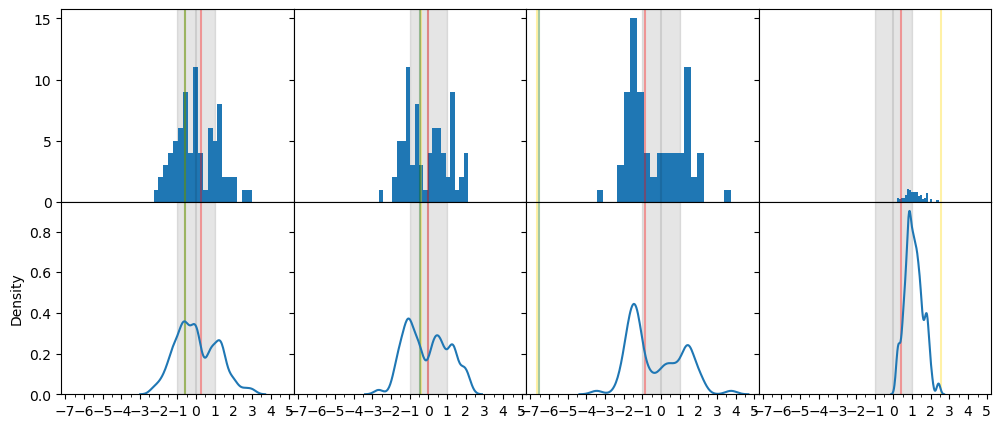

In [61]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(12,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])
fidbias2 = (np.mean(s[:,:-1], axis=0) - df.loc['10818'].to_numpy()[2:]) / np.std(s[:,:-1], axis=0)

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]

[ax[0,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias2[i], color='gold', alpha=.35) for i in range(3)]

[ax[0,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias3[i], color='darkgreen', alpha=.35) for i in range(3)]

[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

[ax[i,-1].axvline(np.mean(np.abs(fidbias)), color='red', alpha=.35) for i in range(2)]
[ax[i,-1].axvline(np.mean(np.abs(fidbias2)), color='gold', alpha=.35) for i in range(2)]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False, bins=20)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i], bw_adjust=0.5)
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.abs(normed_bias), axis=1), density=True, bins=20)
sns.kdeplot(np.mean(np.abs(normed_bias), axis=1), ax=ax[1,3], bw_adjust=0.5)

# ax[0,0].set_xlim(-3.5,3.5)
from matplotlib.ticker import LinearLocator, MultipleLocator
#ax[0,0].xaxis.set_major_locator(LinearLocator(11))

ax[0,0].xaxis.set_major_locator(MultipleLocator(1))
ax[0,0].xaxis.set_minor_locator(MultipleLocator(0.5))

In [62]:
err = np.load("/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed5/ensemble_error_v5.1.npy")
err

array([0.00609426, 0.00770746, 0.01331136, ..., 0.01316332, 0.00542797,
       0.00623588], shape=(1359,))

In [ ]:
for i, sn in enumerate(sampled_sims):
    print(sn)
    if sn in bad_nb:

In [ ]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

good_nb = []
bad_nb = []

for i, sn in enumerate(sampled_sims):
    if sn in bad:
        bad_nb.append(normed_bias[i])
    elif sn in good:
        good_nb.append(normed_bias[i])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

for i in range(3):
    ax[0,i].hist(np.asarray(good_nb)[:,i], density=False)
    sns.kdeplot(np.asarray(good_nb)[:,i], ax=ax[1,i])
    ax[0,i].hist(np.asarray(bad_nb)[:,i], density=True)
    sns.kdeplot(np.asarray(bad_nb)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.asarray(good_nb), axis=1), density=True, label="good sims")
sns.kdeplot(np.mean(np.asarray(good_nb), axis=1), ax=ax[1,3])

ax[0,3].hist(np.mean(np.asarray(bad_nb), axis=1), density=True, label="bad sims")
sns.kdeplot(np.mean(np.asarray(bad_nb), axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

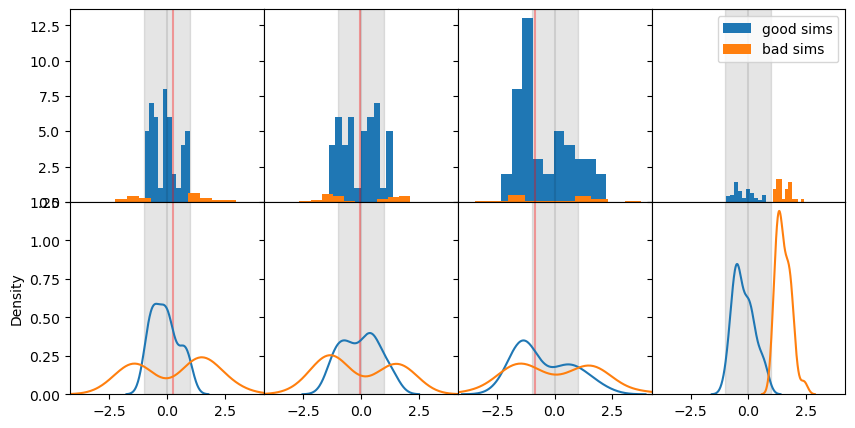

In [35]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

lowbias = np.abs(normed_bias[:,0]) < 1.0

for i in range(3):
    ax[0,i].hist(normed_bias[lowbias][:,i], density=False)
    sns.kdeplot(normed_bias[lowbias][:,i], ax=ax[1,i])
    ax[0,i].hist(normed_bias[~lowbias][:,i], density=True)
    sns.kdeplot(normed_bias[~lowbias][:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(normed_bias[lowbias], axis=1), density=True, label="good sims")
sns.kdeplot(np.mean(normed_bias[lowbias], axis=1), ax=ax[1,3])

ax[0,3].hist(np.mean(np.abs(normed_bias)[~lowbias], axis=1), density=True, label="bad sims")
sns.kdeplot(np.mean(np.abs(normed_bias)[~lowbias], axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

In [47]:
p2 = (2.9766250520507276, 9.6)
p1 = (3.589379844241917, 8.0)

slope, intercept = np.polyfit([p1[1], p2[1]], [p1[0],p2[0]], 1)

3.8053853027834923 8.0
3.9133846421530856 8.0
3.589379844241917 8.0
3.48138529211277 8.0
3.6973862883068946 8.0
4.021383654057061 8.0


/var/folders/8t/k878xr_j2fqgy_993tg3qy7c0000gn/T/ipykernel_7394/3963296080.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(fontsize=20)


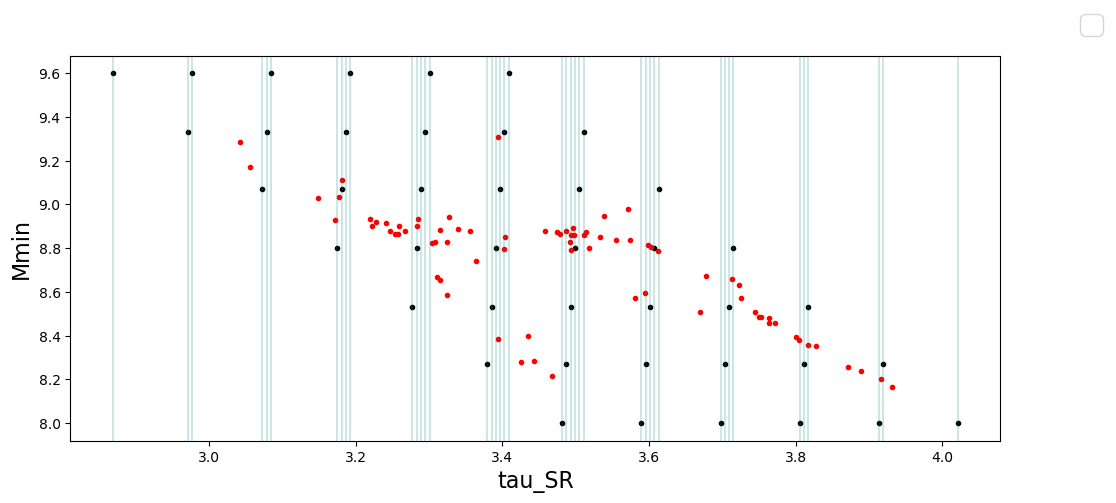

In [48]:
import itertools
fig, ax = plt.subplots(figsize=(12,5))

xMmin_dots = np.asarray(sorted(df['Mmin'].unique()))

unique_pairs = set(
    tuple(sorted(pair)) for pair in zip(df['tau'], df['Mmin'])
)

for pair in unique_pairs:
    x, y = pair
    if y == 8.0:
        print(x,y)
    ax.plot(x, y, marker='.', color='black')


for p in mean_params:
    ax.plot(p[0], p[1], marker='.', color='red')


# ax.plot(degeneracy(xMmin), xMmin, alpha=.75, color='navy', label='Degeneracy Line 1')
# ax.plot(xtau_2ndslope, xMmin, alpha=.75, color='gold', label='Degeneracy Line 2')

for t in df['tau'].unique():
    ax.axvline(t, color='teal', alpha=.2)

ax.set_ylabel('Mmin', fontsize=16)
ax.set_xlabel('tau_SR', fontsize=(16))

fig.legend(fontsize=20)

/Users/emcbride/miniforge3/envs/alfred/lib/python3.11/site-packages/sklearn/base.py:440: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


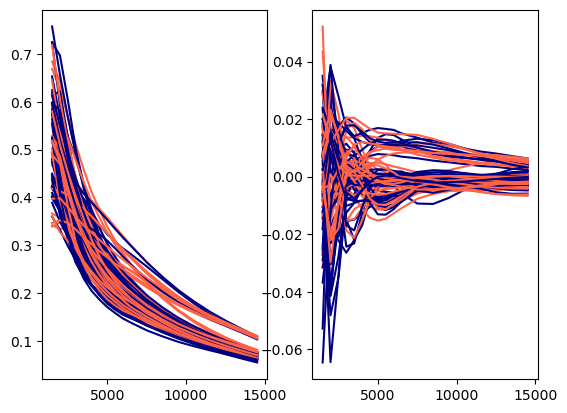

In [31]:
fig, ax = plt.subplots(1,2)

mob = []
for i in range(5):
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

for i, sn in enumerate(sampled_sims):
    spec = utils.spectra(sn)[indices]
    
    if lowbias[i]:
        color = 'navy'
    elif not lowbias[i]:
        color = 'tomato'
    ax[0].plot(ells[indices], spec, color=color)
    ax[1].plot(ells[indices], emulator.mechkemu(df.loc[sn].to_numpy(), mob) - spec, color=color)

In [ ]:
fig, ax = plt.subplots(1,2)

mob = []
for i in range(5):
    emu = summon_emu(f"setrandomseed3/emuv5.1_run{i}")
    mob.append(emu)

for i, sn in enumerate(df.index):
    tspec = utils.spectra(sn)[indices]
    espec = emulator.mechkemu(df.loc[sn].to_numpy(), mob)
    residual =  espec - tspec
    
    # if lowbias[i]:
    #     color = 'navy'
    # elif not lowbias[i]:
    #     color = 'tomato'
    ax[0].plot(ells[indices], tspec, color='navy', alpha=.1)
    ax[0].plot(ells[indices], espec, color='tomato', alpha=.1)
    ax[1].plot(ells[indices], residual, color='black', alpha=.1)

In [ ]:
min_z = []
for redshifts in all_z:
    min_z.append(redshifts.min())


In [ ]:
np.asarray(min_z).max(), df.index[np.asarray(min_z).argmax()]

In [ ]:
y_interp = np.interp(x_interp, x, y)

In [ ]:
all_z[0]

In [49]:
len(all_z)

NameError: name 'all_z' is not defined

In [56]:
emulator.kemu(params, **emu)

array([19.483662, 19.652695, 25.126945, 35.263508, 37.345432, 43.944763],
      dtype=float32)

In [55]:
dataset

array([[0.00622228, 0.0050676 , 0.002469  , 0.00113893, 0.0010514 ,
        0.00075786],
       [0.00830885, 0.00718722, 0.0043405 , 0.00253528, 0.00239869,
        0.00191337],
       [0.00527682, 0.00451011, 0.0026106 , 0.00145592, 0.00137088,
        0.00107219],
       ...,
       [0.00511369, 0.0042389 , 0.00220115, 0.00108949, 0.00101319,
        0.00075294],
       [0.00791119, 0.00691913, 0.00434515, 0.00264884, 0.00251731,
        0.00204509],
       [0.00322261, 0.00271509, 0.0014936 , 0.00078801, 0.00073769,
        0.00056334]], shape=(6797, 6))

On 0th sample
[20.05502  20.238495 25.931267 36.48258  38.652386 45.531788]
On 1000th sample
[20.263754 20.452654 26.225697 36.929516 39.131622 46.11424 ]
On 2000th sample
[21.052195 21.261665 27.339996 38.62463  40.95029  48.326042]
On 3000th sample
[21.749329 21.977386 28.32838  40.132828 42.56902  50.29753 ]
On 4000th sample
[20.06406  20.247818 25.94401  36.50185  38.673145 45.556942]
On 5000th sample
[20.86573  21.070267 27.076038 38.222588 40.518925 47.801178]
On 6000th sample
[20.143944 20.329784 26.056686 36.67286  38.856586 45.779823]
On 7000th sample
[21.039797 21.248922 27.322382 38.59784  40.92157  48.29098 ]
On 8000th sample
[20.451675 20.645443 26.490932 37.33255  39.563942 46.639626]
On 9000th sample
[19.947084 20.12786  25.779163 36.251785 38.404957 45.23123 ]
On 10000th sample
[20.72407  20.924932 26.87579  37.917747 40.191753 47.40318 ]
On 11000th sample
[20.193903 20.380987 26.127073 36.779797 38.971134 45.919064]
On 12000th sample
[20.83917  21.042997 27.038576 38.1

(0.0001, 0.1)

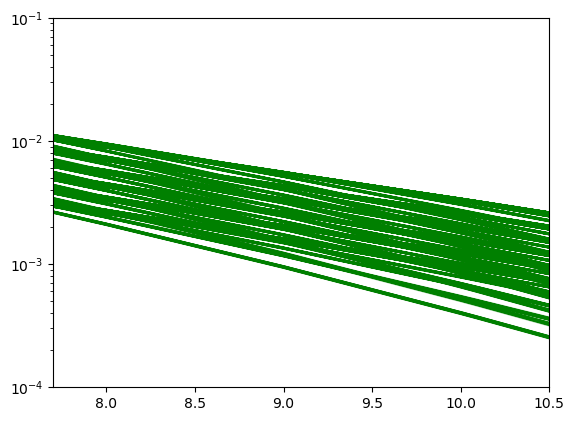

In [54]:
fig, ax = plt.subplots()

import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"

z_interp = np.array([7.7, 8.0, 9.0, 10.0, 10.1, 10.5])

dataset = np.zeros((len(df), len(z_interp)))
features = np.zeros((len(df), 5))

all_SFR = []
all_z  = []
for i, sn in enumerate(df.index):
   #ax.semilogy(all_z[i],all_SFR[i], color='green', alpha=.01)
    filename = f"simu{sn}_diagnostics.dat"
    path = os.path.join(directory, filename)
    fdata = np.genfromtxt(path).T

    SFR_interp = np.interp(z_interp, fdata[0][::-1], fdata[4][::-1])

    dataset[i] = SFR_interp
    features[i] = df.loc[sn].to_numpy()

    ax.semilogy(z_interp, SFR_interp, color='green', alpha=.2)

emu = {'scalerX': nn.scalerX,
       'scalerY': nn.scalerY,
       'model': nn.model}

for i, p in enumerate(s[:,-1]):
    if i % 1000 != 0:
        continue

    print(f"On {i}th sample")
    params = cp.deepcopy(df.loc[config.sn].to_numpy())
    params[2:] = p
    print(emulator.kemu(params, **emu))
    ax.semilogy(z_interp, emulator.kemu(params, **emu), color='deeppink', alpha=.1)

# ax.set_xlim(5.0, 20.0)
ax.set_xlim(z_interp.min(), z_interp.max())
ax.set_ylim(10e-5, 10e-2)



In [40]:
s,l = utils.load_samples(f"/Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless")

Loading samples from /Users/emcbride/Datasets/LoReLi/inference/productionruns3_mechaemu_simu10818/CMB-HD/noiseless...


In [53]:
validation_sims = np.load(f'{base_dir}/emulators/setrandomseed3/validation_sims.npy', allow_pickle=True)
training_files = np.load(f"{base_dir}/emulators/setrandomseed3/emuv5.1_run0/training_files.npz", allow_pickle=True)

hyperparameters = training_files['config'].item()
hyperparameters['uncertainties'] = None
hyperparameters

nn = emulator.NeuralNetwork(hyperparameters, dataset=dataset, features=features, verbose=True)
nn.prep_data()
nn.regress()

prepping data for regression...
logging input data...
scaling features and data...
running regression with config:
	 {'neurons': 32, 'epochs': 500, 'nlayers': 2, 'uncertainties': None, 'batch_normalize': True, 'add_dropout': True, 'early_stop': True, 'reduce_lr': True}
Epoch 1/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4692 - val_loss: 0.7048 - learning_rate: 0.0010
Epoch 2/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4823 - val_loss: 0.3695 - learning_rate: 0.0010
Epoch 3/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step - loss: 0.3293 - val_loss: 0.1906 - learning_rate: 0.0010
Epoch 4/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 0.2503 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 5/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 0.2157 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 6/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 846us/step - loss: 0.1866 - val_loss: 0.0618 - learning_rate: 0.0010
Epoch 7/500
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 0.1724 

In [ ]:
fig, ax = plt.subplots()

import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"

dataset = np.zeros((len(df), 5))
features = np.zeros((len(df), 5))

# Regex to extract the first number in the filename
number_pattern = re.compile(r'\d+')

for filename in os.listdir(directory):
    path = os.path.join(directory, filename)
    if os.path.isfile(path):
        match = number_pattern.search(filename)
        if match:
            number = int(match.group())
         #   print(f"Found number {number} in file: {filename}")

            fdata = np.genfromtxt(path).T
            ax.semilogy(fdata[0], fdata[4], color='green', alpha=.2)

ax.set_xlim(5.0, 20.0)



In [ ]:
fig, ax = plt.subplots(2,5, sharex='col', sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

# [a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
# [ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
# [ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
# [a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

sampled_params = np.asarray(sampled_params)

for i in range(5):
    ax[0,i].hist(df.to_numpy()[:,i], density=False, color='black', alpha=.2)
    sns.kdeplot(df.to_numpy()[:,i], ax=ax[1,i], color='black', alpha=.2)

    ax[0,i].hist(sampled_params[lowbias][:,i], density=False)
    sns.kdeplot(sampled_params[lowbias][:,i], ax=ax[1,i])
    ax[0,i].hist(sampled_params[~lowbias][:,i], density=True)
    sns.kdeplot(sampled_params[~lowbias][:,i], ax=ax[1,i])



# ax[0,0].set_xlim(-4.2,4.2)
ax[0,3].legend()

In [ ]:
fig, ax = plt.subplots(2,4, sharex=True, sharey='row', figsize=(10,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

fidbias = np.array([ 2.68827123e-01, -2.01797354e-02, -8.61174376e-01])

[a.axvline(0.0, color='black', alpha=.1) for a in ax.flatten()]
[ax[0,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[ax[1,i].axvline(fidbias[i], color='red', alpha=.35) for i in range(3)]
[a.axvspan(-1,1, color='black', alpha=.1) for a in ax.flatten()]

for i in range(3):
    ax[0,i].hist(np.asarray(normed_bias)[:,i], density=False)
    sns.kdeplot(np.asarray(normed_bias)[:,i], ax=ax[1,i])
    # ax[0,i].hist(np.asarray(normed2)[:,i], density=True)
    # sns.kdeplot(np.asarray(normed2)[:,i], ax=ax[1,i])

ax[0,3].hist(np.mean(np.asarray(normed_bias), axis=1), density=True)
sns.kdeplot(np.mean(np.asarray(normed_bias), axis=1), ax=ax[1,3])

ax[0,0].set_xlim(-4.2,4.2)

In [ ]:
survey_labels = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setups = ['noiseless', 'noiseless_Planck', 'addnoise', 'addnoise_Planck']

chains_all = []

for survey in survey_labels:
    chains = []
    for setup in setups:
        s, l = utils.load_samples(f"{base_dir}/inference/productionruns2_mechaemu/{survey}/{setup}")
        chains.append(s)

    chains_all.append(chains)

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 0
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 1
chains = chains_all[index]



for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

line_kwargs = {}

ndim = 4

index = 2
chains = chains_all[index]

for i, chain in enumerate(chains): 
     chain = make_tauchains(chain, truths=df.loc[config.sn].to_dict()) 
     fig = corner.corner(chain, color=colors[i], fig=fig, levels=[0.393, 0.675, 0.864], 
                         plot_datapoints=False, hist_kwargs={'density': True})

     means = chain.mean(axis=0)
     axes = np.array(fig.axes).reshape((len(means), len(means)))

     print(true_params)
     print(means)
     line_kwargs['color'] = colors[i]
     plot_vlines(means, axes, **line_kwargs)
     line_kwargs['color'] = 'black'
     plot_vlines(true_params[2:], axes, **line_kwargs)

line_kwargs['color'] = 'red'
# line_kwargs['ls'] = '--'


# Create custom legend handles
handles = [Patch(color=c, label=l) for c, l in zip(colors[:len(setups)], setups)]

# Create the legend
plt.legend(handles=handles, loc='upper right')

In [ ]:
from datetime import datetime
import os
import re

directory = f"{base_dir}/metadata/diagnostic_files"
pattern = re.compile(r'(\d{5})')  # Expects date format like '20240708'

SFR_histories = {}

for filename in os.listdir(directory):
    filepath = os.path.join(directory, filename)
    if os.path.isfile(filepath):
        match = pattern.search(filename)
        if match:
            sn = match[0]
            diagnostic_file = np.genfromtxt(filepath)
            z = diagnostic_file[:,0]
            SFR = diagnostic_file[:,4]

            history = {'z': z,
                       'SFR': SFR}
            
            SFR_histories[sn] = history

In [ ]:
SFR_histories[sfrh]['SFR']

In [ ]:
# features = np.

min_z = []
fig, ax = plt.subplots()

for sfrh in SFR_histories:
    if sfrh not in df.index:
        continue
    hist = SFR_histories[sfrh]
    z = hist['z']
    sfr = hist['SFR']

    min_z.append(z.min())

    ax.semilogy(z, sfr, color='blue', alpha=.25)

ax.semilogy(SFR_histories[config.sn]['z'], SFR_histories[config.sn]['SFR'], color='gold', alpha=1.0)

ax.set_xlim(5.0,20.0)


In [ ]:
features = np.zeros((len(df), len(df.columns)))
dataset = np.zeros((len(df), ))

In [ ]:
whatthetau(df.loc[config.sn].to_numpy())[0]

In [ ]:
fig, ax = plt.subplots(4, len(survey_labels), sharex=True, sharey='row', figsize=(15,15))
fig.subplots_adjust(wspace=0.0, hspace=0.01)

for i, label in enumerate(survey_labels):
    chains = chains_all[i]
    # lps = lps_all[i]
    # datas = datas_all[i]
    # nruns = len(chains)
    for n, setup in enumerate(setups):
        chain = chains[n]
        # lp = lps[n]
        # data = datas[n]

        quantile_lines = [[0.16, 0.84]] #* len(data)  # one [0.16, 0.84] list per violin

        # if i == 0:
        #     A = False
        # if i > 0:
        #     A = True

        chain = make_tauchains(chain, A=True, dropA=True, truths=df.loc[config.sn].to_dict())

        for ip, p in enumerate(true_params[2:]):
            ax[ip,i].axhline(p, alpha=.2, color='black')
            ax[ip,i].violinplot(chain[:,ip], [n+1], points=40, widths=0.5,
                        showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
                        bw_method='silverman')
            
    # for ip, p in enumerate(true_params[2:]):
    #     ax[ip,i].axhline(p, alpha=.2, color='black')
    #     ax[ip,i].violinplot(chain[:,ip], [n+2], points=40, widths=0.5,
    #                 showmeans=True, showextrema=True, showmedians=False, quantiles=quantile_lines,
    #                 bw_method='silverman')

    ax[3,i].set_xticks(np.arange(1, len(setups)+1))
    ax[3,i].set_xticklabels([f"{survey} {setup}" for si, setup in enumerate(setups)])
        
    ax[0,i].set_title(f'{label}', fontsize=12)


In [ ]:
match = (df.drop(columns='tau') == df.loc[config.sn].drop(labels='tau')).all(axis=1)

# Get matching rows
matching_rows = df[match]
matching_rows

In [ ]:
for sn in df[df['fesc']==.275].index:
    if sn
    if np.abs(df.loc[sn]['tau'] - df['tau'].mean()) < .1:
        print(df.loc[sn])

In [ ]:
priors

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

i = 2

chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtruezeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])


chain, lp = utils.load_samples(f"{base_dir}/inference/productionruns_fittingtrue2zeus/CMB-HD{setup}")
A = False
chain = make_tauchains(chain, A=A)
print(f"Setup {dir[i]} has {chain.shape} samples")
#  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                            hist_kwargs={'density':True}, plot_datapoints=False,
                            levels=[0.393, 0.675, 0.864], fig=fig)

axes = np.array(fig.axes).reshape((ndim, ndim))


plot_kwargs['color'] = 'gray'
# Get indices of values sorted in descending order
top_indices = np.argsort(lp)[-20:][::-1]  # top 20, highest first
for top in top_indices:
    plot_vlines(chain[top], axes, **plot_kwargs)


MAP = chain[np.argmax(lp)]
print(f"MAP values are: {MAP}")
plot_kwargs['color'] = colors[i]
plot_kwargs['ls'] = '-'
plot_kwargs['alpha'] = .5
plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['alpha'] = 1.0
plot_kwargs['ls'] = '--'
plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# # Create custom legend handles
# handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# # Create the legend
# fig.legend(handles=handles, loc='upper right')

In [ ]:
np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])

In [ ]:
# Build the full dataframe
dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10))

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
print(f"True values are: {truths}")

for i, chain in enumerate(chains):
    lp = lps[i]
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {dir[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                         range=np.vstack([priors, np.array([Planck - 5 * Planck_err, Planck + 5 * Planck_err])])[2:],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    MAP = chain[np.argmax(lp)]
    print(f"==========================")
    print(f"Setup {dir[i]}")
    print(f"==========================")
    print(f"MAP values are: {MAP}")
    plot_kwargs['color'] = colors[i]
    plot_kwargs['ls'] = '-'
    plot_kwargs['alpha'] = .5
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

    plot_kwargs['alpha'] = 1.0
    plot_kwargs['ls'] = '--'
    plot_vlines(MAP, axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:len(chains)], dir)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
mcmcdir = "productionruns3"

pnames = [*df.columns[2:], 'tau_CMB']
survey_list = ['CMB-HD', 'CMB-S4', 'SO-LAT']
setup_list = ['', '_noise', '_Planck', '_noise_Planck']


dfs = []
for survey in survey_list:
    for setup in setup_list:

        s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{survey}{setup}")
        chain = make_tauchains(s)
        df_chain = pd.DataFrame(chain, columns=pnames)
        df_chain['survey'] = survey

        if 'noise' in setup:
            noise = True
        else:
            noise = False
        if 'Planck' in setup:
            Planck = True
        else:
            Planck = False
        
        df_chain['noise'] = noise
        df_chain['Planck'] = Planck

        dfs.append(df_chain)

df_all = pd.concat(dfs, ignore_index=True)


In [ ]:
df_long = df_all.melt(
    id_vars=['survey', 'noise', 'Planck'],
    value_vars=pnames,  # e.g., ['param_1', ..., 'param_5']
    var_name='parameter',
    value_name='value'
)

df_long

In [ ]:
g = sns.catplot(
    data=df_long[df_long['noise'] == False],
    x='survey',             # Group along x-axis by this metadata
    y='value',
    col='parameter',        # One plot per parameter
    kind='violin',
    inner='quart',
    split=True,
    hue='Planck',            # Add another dimension
    dodge=True,
    sharey=False,
    col_wrap=2,
    height=4,
    aspect=1.2
)

for i, ax in enumerate(g.axes.flat):
    print(truths[i])
    ax.axhline(truths[i], color='black', zorder=0)
    ax.set_ylabel(pnames[i])

g.set_xlabels('')

g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.85)
#g.fig.suptitle("Violin Plots of MCMC Parameters by Region and Model")


In [ ]:
fig, ax = plt.subplots(1,4)

for i, param in enumerate(truths):
    sns.violinplot(data=df_long, x='', ax=ax[i], hue='noise')

In [ ]:
fig, ax = plt.subplots(2, len(survey_list), sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

        data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
        data2 = np.load(f"{base_dir}/inference/productionruns1/{experiment}{setup}/data.npz", allow_pickle=True)

        if 'noise' in setup:
            print(f"{experiment} data is: {data['datapoints']}")

        # print(f"Old error: {data2['err']}")
        # print(f"New error: {data['err']}")
        # print()
        # print(f"New / Old: {data['err'] / data2['err']}")
        # print()

        ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
                            yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        ax[1,i].errorbar(ells[indices][data2['lmask']], data2['datapoints'],
                            yerr=err_fit[data2['lmask']], color=colors[j], label=f"{experiment}{setup}")

        # if 'noise' not in setup:
        #     ax[0,i].plot(ells[indices][data['lmask']], data['datapoints'], color=colors[j], label=f"{experiment}{setup}")
        #     ax[1,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_fit[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
        # else:
        #     ax[0,i].errorbar(ells[indices][data['lmask']], data['datapoints'],
        #                     yerr=err_obs[data['lmask']], color=colors[j], label=f"{experiment}{setup}")
            
        ax[0,i].legend()

ax[0,0].set_ylim(0.0, 1.0)

In [ ]:
truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])
truths

In [ ]:
truths

In [ ]:
def playtheviolons(chains):
    psamples = np.zeros((len(chains), chains[0].shape[0], len(truths)))

    for ic, chain in enumerate(chains):
        print(f"Now on chain {ic} which looks like {chain.shape}")
        chain = make_tauchains(chain, A=True)
        for ip in range(len(truths)):
            psamples[ic,:,ip] = chain[:,ip]

    return psamples

allparamchains = []
# Loop over subfigures and add a simple plot in each
for chains in [chains_CMBHD, chains_S4, chains_SOLAT]:
    print(chains[0].shape)
    param_chains = playtheviolons(chains)
    print(param_chains.shape)
    allparamchains.append(param_chains)

In [ ]:
prior_draw = draws(int(120000))
prior_draw.shape

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw[:,2:], A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

prior_chain = make_tauchains(prior_draw, A=False)
fig = corner.corner(prior_chain, color='black', labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)

for i, chain in enumerate(chains_CMBHD):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)



plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-HD{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
print("CMB-HD no Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[0], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[0], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
print("CMB-HD and Planck")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chains_CMBHD[2], A=A), axis=0) - truths) / np.std(make_tauchains(chains_CMBHD[2], A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
print("CMB-HD and Planck + noise")
print('=========================')
for pi, param in enumerate((np.mean(make_tauchains(chain, A=A), axis=0) - truths) / np.std(make_tauchains(chain, A=A), axis=0)):
    if pi ==3:
        print(f"mean value of tau is {param:.3f} sigma away from true value...")
    else:
        print(f"mean value of {df.columns[2+pi]} is {param:.3f} sigma away from true value...")

In [ ]:
for i, chain in enumerate(chains_S4):
    chi2_contribution(chain.mean(axis=0), model, data, err, truths=None)

In [ ]:
theta = fill(s.mean(axis=0), data['truths'].item(), df.columns[2:])
theta

In [ ]:
s[::1000].shape

In [ ]:
fig, ax = plt.subplots(4, len(survey_list), sharex=True, sharey=True, figsize=(15,5))
fig.subplots_adjust(wspace=0.0, hspace=0.0)

for i, experiment in enumerate(survey_list):

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=False)
    err_obs =np.sqrt(np.diag(err_cov))

    err_cov = surveys.error_cov(ells[indices],
                            utils.spectra(config.sn)[indices],
                            surveys.telescopes[experiment],
                            include_emulator=True)
    err_fit =np.sqrt(np.diag(err_cov))
  #  print(f"err={err}")

    for j, setup in enumerate(setup_list):
     #   print(f"{experiment}{setup}")

      data = np.load(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}/data.npz", allow_pickle=True)
      s, l = utils.load_samples(f"{base_dir}/inference/{mcmcdir}/{experiment}{setup}")
      chi2_all = chi2_contribution(s[::100], lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      chi2 = chi2_contribution(s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[:,data['lmask']],
                                data['datapoints'],
                                data['err'], truths=data['truths'].item())
      
      ax[j,i].plot(data['ells'], chi2_all.T, color=colors[j], alpha=.01)
      ax[j,i].plot(data['ells'], chi2.flatten(), color='black', label=f'{experiment}{setup}')
      ax[j,i].legend()

ax[0,0].set_ylim(0.0, 4.0)

In [ ]:
s.mean(axis=0), lambda params: emulator.kemu(params, **emu)[data['lmask']],
                                  data['datapoints'],
                                  data['err'], truths=data['truths'].item()

In [ ]:
# Build the full dataframe

survey_names = ['Survey A', 'Survey B', 'Survey C']

dfs = []
for s in range(S):
    df = pd.DataFrame(chains[s], columns=[f'param_{i+1}' for i in range(P)])
    df['survey'] = survey_names[s]
    dfs.append(df)

# Combine all surveys into one dataframe
df_all = pd.concat(dfs, ignore_index=True)

# Melt to long form for Seaborn
df_long = df_all.melt(id_vars='survey', var_name='parameter', value_name='value')


In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_S4):
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'CMB-S4{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=(10,10)) 

ndim = 4
#chain_colors = ['gold', 'blue', 'green']
plot_kwargs = {'color': 'black',
               'alpha': 1.0,
               'ls': '-'} 

truths = np.concatenate([df.loc[config.sn][2:], whatthetau(df.loc[config.sn].to_numpy())])

for i, chain in enumerate(chains_SOLAT):
    if (i == 3) or (i==2):
        continue
    A = True
    chain = make_tauchains(chain, A=A)
    print(f"Setup {setup_list[i]} has {chain.shape} samples")
  #  print(f"R={gelman_rubin_rhat(chain.reshape(config.nwalkers, 2000, chain.shape[1]))}")
    fig = corner.corner(chain, color=colors[i], labels=[*df.columns[2:], 'tau_CMB'],
                                hist_kwargs={'density':True}, plot_datapoints=False,
                                levels=[0.393, 0.675, 0.864], fig=fig)
    
    axes = np.array(fig.axes).reshape((ndim, ndim))

    plot_kwargs['color'] = colors[i]
    plot_vlines(np.mean(make_tauchains(chain, A=A), axis=0), axes, **plot_kwargs)

plot_kwargs['color'] = 'black'
plot_kwargs['ls'] = ':'
plot_vlines(truths, axes, **plot_kwargs)

# Create custom legend handles
handles = [Patch(color=c, label=f'SO-LAT{l}') for c, l in zip(colors[:4], setup_list)]

# Create the legend
fig.legend(handles=handles, loc='upper right')